<a href="https://colab.research.google.com/github/ymufidanisa/Undergraduate-Projects/blob/Final-Project/Pengolahan_Kontras_Teoritis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Yasmin Mufidanisa**
**120290022**

**Script Pengolahan Data Tugas AKhir**

# Perhitungan Teoritis

In [ ]:
#Yasmin Mufidanisa
#120290022
#Sains Atmosfer dan Keplanetan
!pip install skyfield

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 446.0/446.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.3/232.3 kB 6.6 MB/s eta 0:00:00


In [ ]:
#library yang dipakai
import numpy as np
import math
import os
import datetime
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from skyfield.api import load
from skyfield.framelib import ecliptic_frame
from skyfield.api import load, wgs84, S, E
from numpy import cov
from scipy.stats import pearsonr,spearmanr
from sklearn.metrics import r2_score
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

In [ ]:
#name = '/content/data_waktu.txt'
#import pengolahan dari AIJ
name = '/content/kontras_observasi.txt'
data = open(name,'r')
dataload = data.readlines()
data.close()

#print(json.dumps(dataload, indent=2))

for line in dataload :
  newline = line.replace("\n","")
  value = newline.replace("\t",";")
  newvalue = value.replace(',','.')
  listline = newvalue.split(";")
#  print(listline[])
#  time = datetime.datetime.strptime(newline,"%d/%m/%Y %H:%M:%S")
  time = datetime.datetime.strptime(listline[0],"%Y-%m-%d_%H-%M-%S") #sesuain sm format penamaan yg dipake

In [ ]:
#bikin list kosong
list_t = []
moon_ra = []
moon_dec = []
moon_d = []
moon_alt = []
moon_az = []
moon_w = []
moon_arcv = []
moon_daz = []
s_d = []
moon_angle = []
p_angle = []
arcl = []
moon_age = []
moon_illuminated = []
mnp = []
mlp = []
mtwi = []
mtw = []
moondia = []
cdtw = []
Astr = []
c_schaefer = []
c_crumey = []
c_obs = []
sun_alt = []
sun_az = []
# list_t=[];moon_ra=[];moon_dec=[];moon_d=[];moon_alt=[];moon_az=[]
# moon_w=[];moon_arcv=[];moon_daz=[];s_d=[];moon_angle=[];p_angle=[]
# arcl=[];moon_age=[];moon_illuminated=[];mnp=[];mlp=[];mtwi=[];mtw=[]
# moondia=[];cdtw=[];Astr=[];c_schaefer=[];c_crumey=[];c_obs=[]
# sun_alt = [];sun_az = []


#Mulai Perhitungan
#for name in dirfile :

for line in dataload :
  newline = line.replace("\n","")
  value = newline.replace("\t",";")
  newvalue = value.replace(',','.')
  listline = newvalue.split(";")
  time = datetime.datetime.strptime(listline[0],"%Y-%m-%d_%H-%M-%S") #sesuain sm format penamaan yg dipake
#  time = datetime.datetime.strptime(newline,"%d/%m/%Y %H:%M:%S")
  #simpen nilai kontras observasi
  obs_contrast = float(listline[1])
  c_obs.append(obs_contrast)


  ts = load.timescale()
  t = ts.utc(time.year, time.month, time.day, time.hour, time.minute, time.second)
  list_t.append(time)
  #t = ts.now()

  #panggil ephemeris dan objek yg dipake
  eph = load('de440.bsp') #ini ephemerisnya
  sun, moon, earth = eph['sun'], eph['moon'], eph['earth']
  e = earth.at(t)
  s = e.observe(sun).apparent()
  m = e.observe(moon).apparent()
  delta = moon.at(t).observe(sun).apparent()

  #lokasi Pengamatan
  top = wgs84.latlon(5.357194444 * S, 105.3115833 * E, elevation_m=90)

  #Alt Az Bulan dan matahari
  a = (earth + top).at(t).observe(moon).apparent()
  m_alt, m_az, m_distance, m_alt_rate, m_az_rate, m_range_rate = (a.frame_latlon_and_rates(top))

  b = (earth + top).at(t).observe(sun).apparent()
  s_alt, s_az, s_distance, s_alt_rate, s_az_rate, s_range_rate = (b.frame_latlon_and_rates(top))

  #Phase bulan
  slat, slon, _ = s.frame_latlon(ecliptic_frame)
  mlat, mlon, _ = m.frame_latlon(ecliptic_frame)
  s_ra,s_dec,s_distance = s.radec()
  m_ra,m_dec,m_distance = m.radec()
  phase = (mlon.degrees - slon.degrees) % 360.0

  #umur Bulan
  age = (phase/360)*29.53

  #persen fase bulan
  percent = 100.0 * m.fraction_illuminated(sun)

  #sudut fase
  frac = m.fraction_illuminated(sun)
  phi = 2*frac - 1
  phase_angle = np.degrees(np.arccos(phi))

  #RA dec dan elongasi
  position = earth.at(t).observe(moon)
  ra, dec, distance = position.radec()
  elongation = m.separation_from(s).degrees

  #Apparent diameter & Width
  Rmoon = 1737.4
  app_moon = np.degrees(np.arctan((Rmoon*2)/distance.km))
  semidiameter_topocentric=app_moon/2
  fullmoon_w = np.pi * ((app_moon/2)*3600)**2
  w = frac * fullmoon_w #luas bulan dalam arcsec2

  #ARCV DAZ
  arcv = m_alt.degrees-s_alt.degrees
  daz = m_az.degrees-s_az.degrees
  if daz < 0 :
    daz = 360+(m_az.degrees-s_az.degrees)
  # "".degrees" buat ubah yg angle jd derajat, supaya bisa di operasiin

  #MOON BRIGHTNESS OUT ATMOSPHERE
  mag= -12.73+0.026*phase_angle+4*10**-9*phase_angle**4
  out_moonbrightness_s10 = (1/w)*2.51**(10-mag)
  out_moonbrightness_mag = -(math.log10(out_moonbrightness_s10))*2.5-26.33

  #Light Loss from Atmosphere
  ##Air Mass Effect
  ###Raylieh
  moon_zenith = float(90-((m_alt.degrees)))
  jure1 = float(math.cos(math.radians(moon_zenith)))
  jur1 = float(0.01*math.sqrt(8.2))
  jur2 = (-30*math.cos(math.radians(moon_zenith)))/(math.sqrt(8.2))
  jur3 = jure1+jur1*math.exp(jur2)
  jur = pow(jur3,-1)

  ###Aerosol
  jue1 = float(0.01*math.sqrt(1.5))
  jue2 = (-30*math.cos(math.radians(moon_zenith)))/(math.sqrt(1.5))
  jue3 = jure1+jue1*math.exp(jue2)
  jue = pow(jue3,-1)

  ##Atmosphere Effect
  ###Rayleigh
  ele = 90
  humid = 0.85
  temp = 25
  kr = 0.1066 * math.exp(-(ele/1000)/8.2)

  #Aerosol
  ke1 = 0.12*pow(1,1.3)
  ke2 = math.exp(-ele/1.5)
  ke3 = math.exp(-ele/1.5)*(1-(0.32/math.log(humid)))**(4/3)
  ke4 = 1+0.33 * math.sin(math.radians(s_ra.hours*15))
  ke5= ke2*ke3
  ke = ke1 *ke3 * ke4

  #Inner Atmospheric Moon Brightness
  bulanmagfc = pow(10,((-16.8-out_moonbrightness_mag)/2.5))
  difmag = float(kr*jur + ke*jue)
  maghlg = bulanmagfc*(pow(10,(-difmag/2.5)))
  bulanmagket = float(-16.8-2.5*(math.log10(maghlg)))
  sunra = s_ra.hours*15

  moon_zenith_distance = float(90-m_alt.degrees)
  theta = np.deg2rad(moon_zenith_distance)
  delAz = np.deg2rad(daz)
  sh = np.deg2rad(s_alt.degrees)
  tw1 = -(7.5*(pow(10,-5))*theta+5.05*pow(10,-3))*delAz
  tw2 = (3.67*pow(10,-4)*theta-0.458)*sh
  tw3 = ((9.17*pow(10,-3))*theta+3.525)*sh
  tw = tw1+tw2+tw3
  twmag1 = pow(10,tw)
  twmag2 = 9.17*pow(10,4)*twmag1
  tw_no_lightpollution = -(math.log10(twmag2)*2.5-27.78)

  a=319.186511755673;b=-46.9419919726453;c=0.434369283318305
  d=2.39138122541257;e=-0.00121311966265414;f=-0.0488735671014705
  g=-0.0396262989070584;h=-0.000000928758741258742;i=0.0000548215089277455
  j=0.001346675592325110;θ=moon_zenith_distance
  Zlp=20 #DIGANTI KLO DAH DPT DATA SQM
  tw_lightpollution= a+b*Zlp+c*θ+d*pow(Zlp,2)+e*pow(θ,2)+f*Zlp*θ+g*pow(Zlp,3)+h*pow(θ,3)+i*Zlp*pow(θ,2)+j*pow(Zlp,2)*θ
  if(tw_no_lightpollution<=tw_lightpollution):
      twmag=tw_no_lightpollution
  else:
      twmag=tw_lightpollution

  #print(twmag)

  moon_brightness_nL = pow(10,(-0.4*(bulanmagket-26.33)))
  twilight_brightness_nL = pow(10,(-0.4*(twmag-26.33)))
  c= ((moon_brightness_nL- twilight_brightness_nL)/twilight_brightness_nL)
  # print('contrast : ', c)

  #Calculate Scahefer Contrast
  dia = (semidiameter_topocentric*2)
  #twlpno = pow(10,(-0.4*(twlp-26.33)))
  eyesns1 = (40/(20))
  eyesns2 = 8.28*pow(twilight_brightness_nL,-0.29)
  eyesns3 = pow(10,eyesns2)
  eyesns4 = (eyesns1 * eyesns3)
  eyesns = eyesns4/3600
  print(eyesns)
  #bulanmagketno = pow(10,(-0.4*(bulanmagket-26.33)))
  cont = (abs(moon_brightness_nL-twilight_brightness_nL))/twilight_brightness_nL
  contsch1 = pow((eyesns/dia),2)
  contsch2 = 2.4*pow(twilight_brightness_nL,-0.1)
  contsch = 0.0028+contsch2*contsch1

  #Calculate Crumey Contrast
 # twilight_brightness_cd=pow(10,((12.58-twmag)/2.5))
  twilight_brightness_cd=108000*pow(10,(-0.4*twmag))
  r1=6.505*pow(10,-4)
  r2=-8.461*pow(10,-4)
  k1=7.633*pow(10,-3)
  k2=-7.174*pow(10,-3)

  A = w/(4.25*pow(10,10))
  cr1 = pow((r1*pow(twilight_brightness_cd,(-1/4))+r2),2)/A
  cr12 = pow(cr1,(3/5))
 # print('Cr1:',cr1)
  cr2 = pow(k1*pow(twilight_brightness_cd,(-1/4))+k2,3/5)
#  print('cr2:',cr2)
  cr3 = pow(cr12+cr2,(5/3))
 # print('cr3:',cr3)


  #masukin ke list
  moon_ra.append(ra._degrees)
  moon_dec.append(dec.degrees)
  moon_d.append(distance.au)
  moon_alt.append(m_alt.degrees)
  moon_az.append(m_az.degrees)
  moon_w.append(w)
  moon_arcv.append(arcv)
  moon_daz.append(daz)
  s_d.append(s_distance.au)
  moon_angle.append(phase)
  p_angle.append(phase_angle)
  arcl.append(elongation)
  moon_age.append(age)
  moon_illuminated.append(percent)
  mnp.append(tw_no_lightpollution)
  mlp.append(tw_lightpollution)
  mtwi.append(twmag)
  mtw.append(tw)
  moondia.append(semidiameter_topocentric)
  cdtw.append(twilight_brightness_cd)
  Astr.append(A)
  c_schaefer.append(contsch)
  c_crumey.append(float(cr3))
  sun_alt.append(s_alt.degrees)
  sun_az.append(s_az.degrees)

0.0005843893267495653
0.0005855690245620703
0.000596373978958766
0.0006019364336797501
0.000613108924057167
0.0006271694272123534


<ipython-input-47-708a3c541eb9>:280: ComplexWarning: Casting complex values to real discards the imaginary part
  c_crumey.append(float(cr3))


0.0006380133193541748
0.0006479537093688206
0.0006622128170418848
0.0006793380767707598
0.0006984027704179984
0.0007214738443554866
0.0007486951158843955
0.0007801278659898822
0.0008203208806843508
0.0008608297309819606
0.0009165132969292928
0.00098456283656393
0.0010687234894131302
0.0011738685408705265
0.0013069127177153196
0.0015049265010424176
0.0017365876546881023


# Tabulasi

In [ ]:
#Bikin Jadi Tabel
dict = {'Waktu (UTC)':list_t,
        'Moon RA':moon_ra,
        'Moon Dec':moon_dec,
        'Moon Distance (AU)':moon_d,
        'Moon ALt':moon_alt,
        'Moon Az':moon_az,
        'Moon Width':moon_w,
        'ARCV':moon_arcv,
        'DAZ':moon_daz,
        'Sun Alt': sun_alt,
        'Sun Az':sun_az,
        'Sun Distance (AU)':s_d,
        'Phase Angle':p_angle,
        'ARCL':arcl,
        'Moon Age (days)':moon_age,
        'Illuminated':moon_illuminated,
        'Observation Contrast':c_obs,
        'Schaefer Contrast': c_schaefer,
        'Crumey Contrast':c_crumey}
df = pd.DataFrame(dict)
df['Observation Contrast'].replace(0, np.NaN, inplace=True)

df['Observation Contrast'] = df['Observation Contrast'].interpolate()

In [ ]:
df

,Waktu (UTC),Moon RA,Moon Dec,Moon Distance (AU),Moon ALt,Moon Az,Moon Width,ARCV,DAZ,Sun Alt,Sun Az,Sun Distance (AU),Phase Angle,ARCL,Moon Age (days),Illuminated,Observation Contrast,Schaefer Contrast,Crumey Contrast
0,2023-03-22 05:06:31,7.874854,0.881332,0.002458,80.549226,46.948498,11086.540679,-3.568406,48.769418,84.117632,358.179080,0.996246,173.011493,6.976700,0.540049,0.371471,0.016680,0.002800,2.142119
1,2023-03-22 05:20:34,7.999340,0.947153,0.002458,82.612778,27.774252,11467.908404,-0.439831,60.015370,83.052609,327.758882,0.996248,172.891445,7.096467,0.550775,0.384326,0.021600,0.002800,2.052728
2,2023-03-22 06:02:34,8.371347,1.143806,0.002459,80.359606,314.184536,12652.872620,5.719441,22.039200,74.640165,292.145336,0.996257,172.530463,7.456598,0.582824,0.424294,0.032160,0.002800,1.721559
3,2023-03-22 06:17:21,8.502244,1.212985,0.002459,77.463900,302.628751,13085.937797,6.287491,14.899706,71.176409,287.729045,0.996259,172.402713,7.584046,0.594099,0.438910,0.037010,0.002800,1.600467
4,2023-03-22 06:41:30,8.716031,1.325951,0.002459,72.144969,292.382689,13811.227083,6.769817,9.223805,65.375152,283.158885,0.996264,172.193326,7.792936,0.612512,0.463399,0.042200,0.002801,1.402414
5,2023-03-22 07:05:19,8.926810,1.437300,0.002460,66.610650,286.919344,14548.119485,7.044094,6.618262,59.566556,280.301082,0.996269,171.986046,7.999722,0.630664,0.488293,0.041980,0.002801,1.207504
6,2023-03-22 07:20:25,9.060418,1.507866,0.002460,63.034817,284.597640,15026.405074,7.175661,5.637352,55.859156,278.960288,0.996272,171.854257,8.131196,0.642168,0.504457,0.032150,0.002801,1.084354
7,2023-03-22 07:32:28,9.167024,1.564162,0.002460,60.159648,283.130054,15414.243311,7.268140,5.065437,52.891508,278.064616,0.996274,171.748894,8.236308,0.651346,0.517569,0.045510,0.002801,0.986473
8,2023-03-22 07:47:29,9.299856,1.634295,0.002461,56.558557,281.638012,15905.205137,7.373715,4.528278,49.184841,277.109734,0.996277,171.617360,8.367527,0.662782,0.534172,0.056890,0.002801,0.865265
9,2023-03-22 08:02:51,9.435762,1.706039,0.002461,52.859276,280.393373,16416.369146,7.474842,4.119434,45.384434,276.273939,0.996280,171.482511,8.502053,0.674481,0.551465,0.042790,0.002801,0.742624


In [ ]:
#saving dataframe
df.to_excel('Kontras_teoritis_Akhir.xlsx')

# Plot Grafik

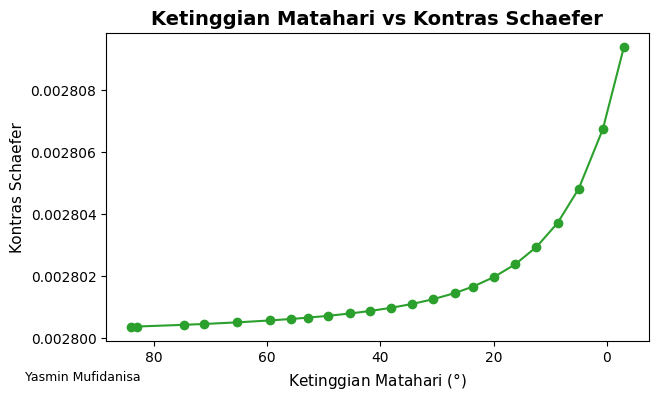

In [ ]:
fig,ax = plt.subplots(figsize=(7,4))
plt.scatter(df['Sun Alt'],df['Schaefer Contrast'],color='tab:green')
plt.plot(df['Sun Alt'],df['Schaefer Contrast'],color='tab:green')
plt.title('Ketinggian Matahari vs Kontras Schaefer',fontsize=14,fontweight='bold',
          ha='center')
plt.xlabel(r'Ketinggian Matahari ($\degree$)',fontsize=11)
plt.ylabel('Kontras Schaefer',fontsize=11)
plt.text(-0.15,-0.13 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)
ax.invert_xaxis()
plt.show()

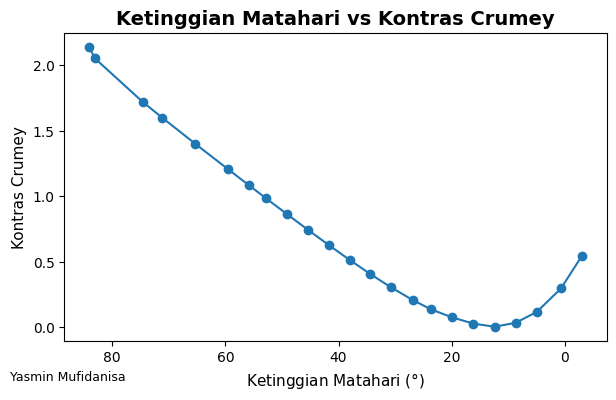

In [ ]:
fig,ax = plt.subplots(figsize=(7,4))
plt.plot(df['Sun Alt'],df['Crumey Contrast'])
plt.scatter(df['Sun Alt'],df['Crumey Contrast'])
plt.title('Ketinggian Matahari vs Kontras Crumey',fontsize=14,fontweight='bold',
          ha='center')
plt.xlabel(r'Ketinggian Matahari ($\degree$)',fontsize=11)
plt.ylabel('Kontras Crumey',fontsize=11)
plt.text(-0.1,-0.13 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)
ax.invert_xaxis()
plt.show()

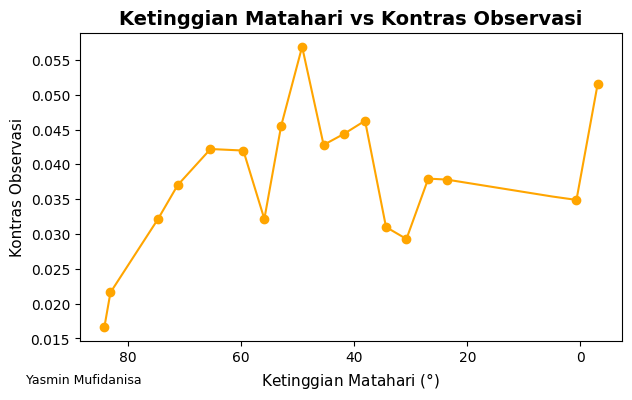

In [ ]:
fig,ax = plt.subplots(figsize=(7,4))
plt.plot(df['Sun Alt'],df['Observation Contrast'],color='orange')
plt.scatter(sun_alt,c_obs,color='orange')
plt.title('Ketinggian Matahari vs Kontras Observasi',fontsize=14,fontweight='bold',
          ha='center')
plt.xlabel(r'Ketinggian Matahari ($\degree$)',fontsize=11)
plt.ylabel('Kontras Observasi',fontsize=11)
plt.text(-0.1,-0.14 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)
ax.invert_xaxis()
plt.show()

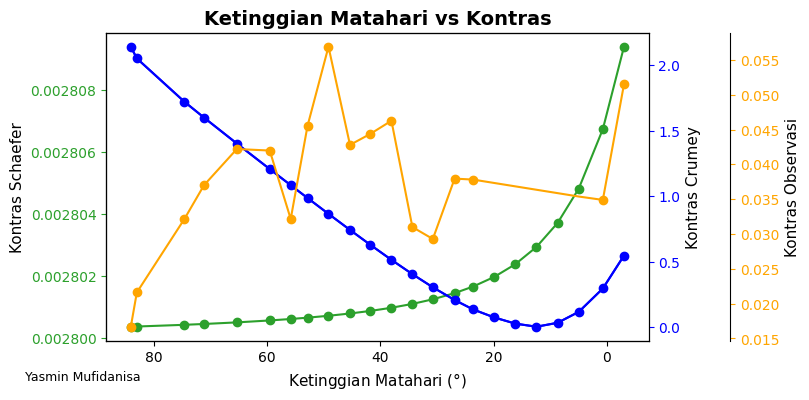

In [ ]:
fig = plt.figure(figsize=(7,4))
ax=fig.add_subplot(111, label="1")
# ax2=fig.add_subplot(111, label="2",frame_on=False)
# ax3=fig.add_subplot(111, label="3",frame_on=False)
ax2 = ax.twinx()
ax3 = ax.twinx()

ax.scatter(df['Sun Alt'],df['Schaefer Contrast'],color='tab:green')
ax.plot(df['Sun Alt'],df['Schaefer Contrast'],color='tab:green')
# ax.title('Ketinggian Matahari vs Kontras Schaefer',fontsize=14,fontweight='bold',
#           ha='center')
ax.set_xlabel(r'Ketinggian Matahari ($\degree$)',fontsize=11)
ax.set_ylabel('Kontras Schaefer',fontsize=11)
plt.text(-0.15,-0.13 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)

ax2.plot(df['Sun Alt'],df['Crumey Contrast'],color='b')
p, = ax2.plot(df['Sun Alt'],df['Crumey Contrast'],color='b')
ax2.scatter(df['Sun Alt'],df['Crumey Contrast'],color='b')
plt.title('Ketinggian Matahari vs Kontras',fontsize=14,fontweight='bold',
          ha='center')
ax2.set_xlabel(r'Ketinggian Matahari ($\degree$)',fontsize=11)
ax2.set_ylabel('Kontras Crumey',fontsize=11)
# ax2.text(-0.1,-0.13 ,"Yasmin Mufidanisa", color='black', ha='left',
#          transform=ax.transAxes, fontsize=9)
ax2.yaxis.set_label_position('right')
ax2.yaxis.tick_right()

ax3.plot(df['Sun Alt'],df['Observation Contrast'],color='orange')
ax3.scatter(sun_alt,c_obs,color='orange')
# plt.title('Ketinggian Matahari vs Kontras Observasi',fontsize=14,fontweight='bold',
#           ha='center')
ax3.set_xlabel(r'Ketinggian Matahari ($\degree$)',fontsize=11)
ax3.set_ylabel('Kontras Observasi',fontsize=11)
ax3.yaxis.set_label_position('right')
ax3.yaxis.tick_right()
ax3.spines.right.set_position(("axes", 1.15))

ax.tick_params(axis='y', colors='tab:green')#, **tkw)
ax2.tick_params(axis='y',colors=p.get_color()) #, **tkw)
ax3.tick_params(axis='y', colors='orange')#, **tkw)

ax.invert_xaxis()
ax2.invert_xaxis()
ax3.invert_xaxis()
plt.show()

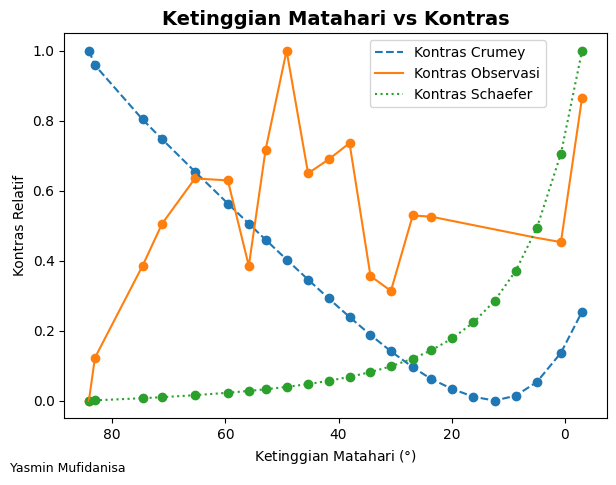

<Figure size 640x480 with 0 Axes>

In [ ]:
x = df['Sun Alt']
y1 = df['Observation Contrast']
y2 = df['Schaefer Contrast']
y3 = df['Crumey Contrast']
y4 = pd.DataFrame(c_obs)

#normalilasi data
y1_norm = (y1 - y1.min()) / (y1.max() - y1.min())
y2_norm = (y2 - y2.min()) / (y2.max() - y2.min())
y3_norm = (y3 - y3.min()) / (y3.max() - y3.min())
y4_norm = (y4 - y4.min()) / (y4.max() - y4.min())

#buat plot
fig,ax = plt.subplots(figsize=(7,5))
plt.plot(x,y3_norm,label='Kontras Crumey',linestyle='--')
plt.plot(x,y1_norm,label='Kontras Observasi')
plt.plot(x,y2_norm,label='Kontras Schaefer',linestyle='dotted')
plt.scatter(x,y3_norm)
plt.scatter(x,y4_norm)
plt.scatter(x,y2_norm)
#plt.yscale('log')
plt.ylabel('Kontras Relatif')
plt.xlabel(r'Ketinggian Matahari ($\degree$)')
ax.invert_xaxis()
plt.title('Ketinggian Matahari vs Kontras',fontsize=14,fontweight='bold',
          ha='center')
plt.text(-0.1,-0.14 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)
plt.legend(bbox_to_anchor=(0.9, 1),loc='upper right')
plt.show()
plt.savefig('gabungan-relatif.png')

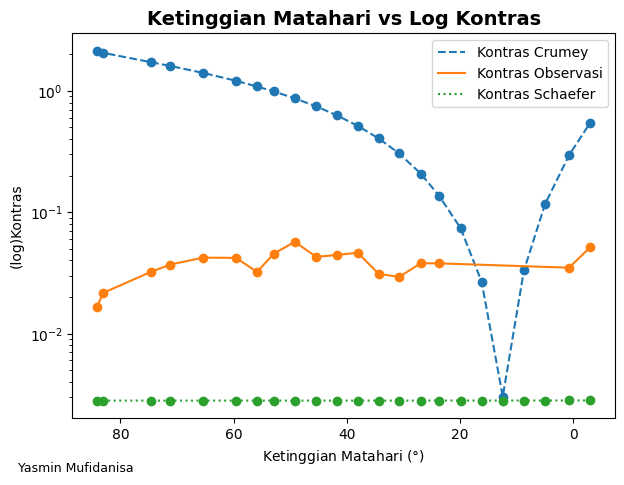

<Figure size 640x480 with 0 Axes>

In [ ]:
fig,ax = plt.subplots(figsize=(7,5))
plt.plot(df['Sun Alt'],df['Crumey Contrast'],label='Kontras Crumey',linestyle='--')
plt.plot(df['Sun Alt'],df['Observation Contrast'],label='Kontras Observasi')
plt.plot(df['Sun Alt'],df['Schaefer Contrast'],label='Kontras Schaefer',linestyle='dotted')
plt.scatter(df['Sun Alt'],df['Crumey Contrast'])
plt.scatter(df['Sun Alt'],c_obs)
plt.scatter(df['Sun Alt'],df['Schaefer Contrast'])
plt.yscale('log')
plt.ylabel('(log)Kontras')
plt.xlabel(r'Ketinggian Matahari ($\degree$)')
ax.invert_xaxis()
plt.title('Ketinggian Matahari vs Log Kontras',fontsize=14,fontweight='bold',
          ha='center')
plt.text(-0.1,-0.14 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)
plt.legend()
plt.show()
plt.savefig('log-gabungan.png')

<ipython-input-26-e0fa1756efd6>:14: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr1,pval),


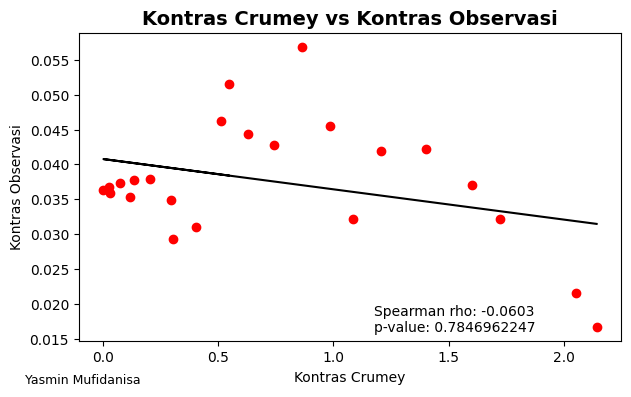

Spearman correlation: -0.060
Covariance: [[ 4.49103954e-01 -1.95393199e-03]
 [-1.95393199e-03  7.72717368e-05]]


<Figure size 640x480 with 0 Axes>

In [ ]:
fig,ax = plt.subplots(figsize=(7,4))
x = df['Crumey Contrast']
y = df['Observation Contrast']
coef = np.polyfit(x,y,1)
poly1d_fn = np.poly1d(coef)
plt.plot(x,y,'ro',x,poly1d_fn(x),'k')
spcorr1,pval = spearmanr(x,y)
#pcorr3,_= pearsonr(c_schaefer,c_crumey)
covariance1 = cov(x,y)
plt.title('Kontras Crumey vs Kontras Observasi',fontsize=14,fontweight='bold',
          ha='center')
plt.xlabel('Kontras Crumey')
plt.ylabel('Kontras Observasi')
plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr1,pval),
             xy=(1.17, 0.016),textcoords="offset points",fontsize=10)
plt.text(-0.1,-0.14 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)
plt.show()
print('Spearman correlation: %.3f' % spcorr1)
#print('Pearsons correlation: %.3f' % pcorr1)
print('Covariance:',covariance1)
plt.savefig('crumey-obs.png')

<ipython-input-27-152c3bc2815b>:14: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr2,pval),


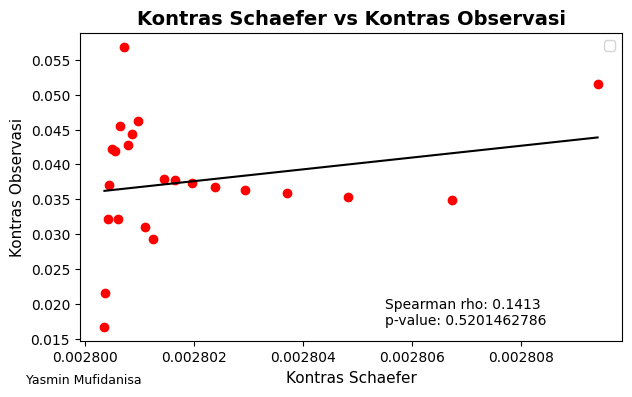

Spearman correlation: 0.141
Covariance: [[5.20347501e-12 4.41757883e-09]
 [4.41757883e-09 7.72717368e-05]]


<Figure size 640x480 with 0 Axes>

In [ ]:
fig,ax = plt.subplots(figsize=(7,4))
x = c_schaefer
y = df['Observation Contrast']
coef = np.polyfit(x,y,1)
poly1d_fn = np.poly1d(coef)
plt.plot(x,y,'ro',x,poly1d_fn(x),'k')
spcorr2,pval = spearmanr(x,y)
#pcorr3,_= pearsonr(c_schaefer,c_crumey)
covariance2 = cov(x,y)
plt.title('Kontras Schaefer vs Kontras Observasi',fontsize=14,fontweight='bold',
          ha='center')
plt.xlabel('Kontras Schaefer',fontsize=11)
plt.ylabel('Kontras Observasi',fontsize=11)
plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr2,pval),
             xy=(0.0028055, 0.017),textcoords="offset points",fontsize=10)
plt.text(-0.1,-0.14 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)
plt.legend()
plt.show()
print('Spearman correlation: %.3f' % spcorr2)
#print('Pearsons correlation: %.3f' % pcorr2)
print('Covariance:',covariance2)
plt.savefig('scahefer-obs.png')

<ipython-input-28-c75d47fd9127>:14: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),


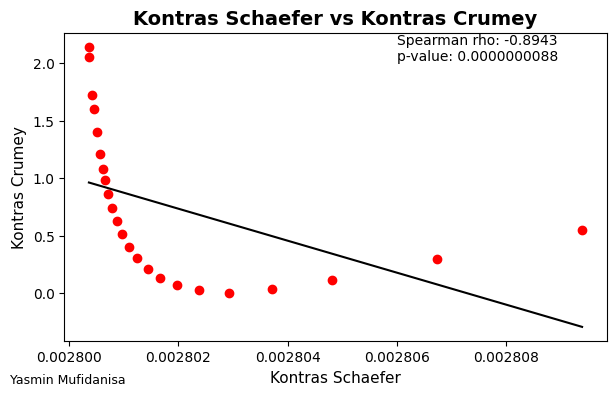

Spearman correlation: -0.894
Covariance: [[ 5.20347501e-12 -7.22949460e-07]
 [-7.22949460e-07  4.49103954e-01]]
p-value: 8.848052618819326e-09


<Figure size 640x480 with 0 Axes>

In [ ]:
fig,ax = plt.subplots(figsize=(7,4))
x = c_schaefer
y = c_crumey
coef = np.polyfit(x,y,1)
poly1d_fn = np.poly1d(coef)
plt.plot(x,y,'ro',x,poly1d_fn(x),'k')
spcorr3,pval = spearmanr(x,y)
#pcorr3,_= pearsonr(c_schaefer,c_crumey)
covariance3 = cov(x,y)
plt.title('Kontras Schaefer vs Kontras Crumey',fontsize=14,fontweight='bold',
          ha='center')
plt.xlabel('Kontras Schaefer',fontsize=11)
plt.ylabel('Kontras Crumey',fontsize=11)
plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),
             xy=(0.002806, 2),textcoords="offset points",fontsize=10)
plt.text(-0.1,-0.14 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)
plt.show()
print('Spearman correlation: %.3f' % spcorr3)
#print('Pearsons correlation: %.3f' % pcorr3)
print('Covariance:',covariance3)
print('p-value:',pval)
plt.savefig('schaefer-crumey.png')

In [ ]:
#print(df.corr('pearson'))

In [ ]:
print(df.corr('spearman'))

                       Moon RA  Moon Dec  Moon Distance (AU)  Moon ALt  \
Moon RA               1.000000  1.000000            1.000000 -0.999012   
Moon Dec              1.000000  1.000000            1.000000 -0.999012   
Moon Distance (AU)    1.000000  1.000000            1.000000 -0.999012   
Moon ALt             -0.999012 -0.999012           -0.999012  1.000000   
Moon Az              -0.522727 -0.522727           -0.522727  0.521739   
Moon Width            1.000000  1.000000            1.000000 -0.999012   
ARCV                  1.000000  1.000000            1.000000 -0.999012   
DAZ                  -0.965415 -0.965415           -0.965415  0.966403   
Sun Alt              -1.000000 -1.000000           -1.000000  0.999012   
Sun Az               -1.000000 -1.000000           -1.000000  0.999012   
Sun Distance (AU)     1.000000  1.000000            1.000000 -0.999012   
Phase Angle          -1.000000 -1.000000           -1.000000  0.999012   
ARCL                  1.000000  1.0000

<ipython-input-30-07bb1304a9ea>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  print(df.corr('spearman'))


<ipython-input-31-e78f839a7ccc>:15: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),


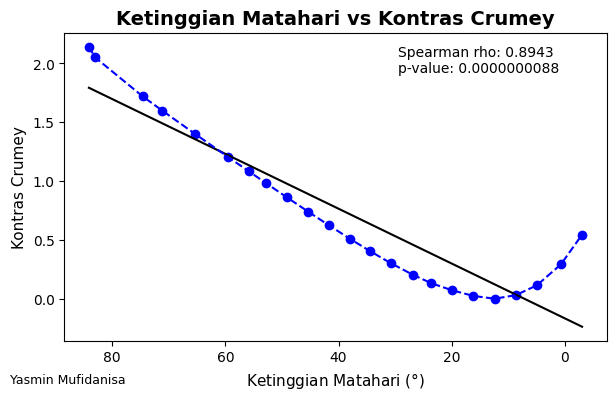

Spearman correlation: 0.894
Covariance: [[7.00301887e+02 1.62991081e+01]
 [1.62991081e+01 4.49103954e-01]]


<Figure size 640x480 with 0 Axes>

In [ ]:
fig,ax = plt.subplots(figsize=(7,4))
x = sun_alt
y = c_crumey
coef = np.polyfit(x,y,1)
poly1d_fn = np.poly1d(coef)
plt.plot(x,y,'bo',x,poly1d_fn(x),'k')
plt.plot(x,y,'b--')
spcorr3,pval = spearmanr(x,y)
#pcorr3,_= pearsonr(c_schaefer,c_crumey)
covariance3 = cov(x,y)
plt.title('Ketinggian Matahari vs Kontras Crumey',fontsize=14,fontweight='bold',
          ha='center')
plt.xlabel(r'Ketinggian Matahari ($\degree$)',fontsize=11)
plt.ylabel('Kontras Crumey',fontsize=11)
plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),
             xy=(39,1.9),textcoords="offset points",fontsize=10)
plt.text(-0.1,-0.14 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)
ax.invert_xaxis()
plt.show()
print('Spearman correlation: %.3f' % spcorr3)
#print('Pearsons correlation: %.3f' % pcorr3)
print('Covariance:',covariance3)
plt.savefig('sun-crum.png')

<ipython-input-32-a3ae8e541c72>:15: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),


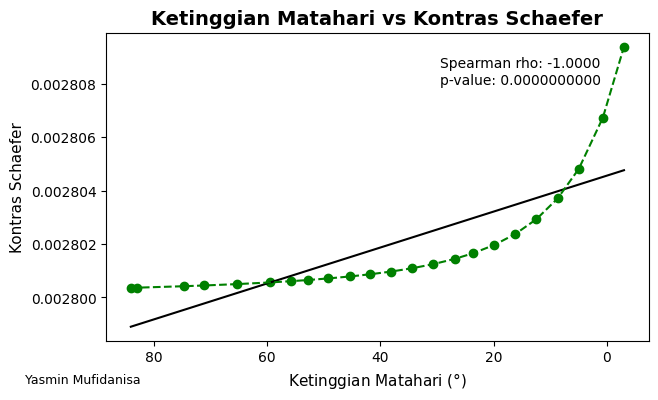

Spearman correlation: -1.000
Covariance: [[ 7.00301887e+02 -4.71199002e-05]
 [-4.71199002e-05  5.20347501e-12]]


<Figure size 640x480 with 0 Axes>

In [ ]:
fig,ax = plt.subplots(figsize=(7,4))
x = sun_alt
y = c_schaefer
coef = np.polyfit(x,y,1)
poly1d_fn = np.poly1d(coef)
plt.plot(x,y,'go',x,poly1d_fn(x),'k')
plt.plot(x,y,'g--')
spcorr3,pval = spearmanr(x,y)
#pcorr3,_= pearsonr(c_schaefer,c_crumey)
covariance3 = cov(x,y)
plt.title('Ketinggian Matahari vs Kontras Schaefer',fontsize=14,fontweight='bold',
          ha='center')
plt.xlabel(r'Ketinggian Matahari ($\degree$)',fontsize=11)
plt.ylabel('Kontras Schaefer',fontsize=11)
plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),
             xy=(39,0.002808),textcoords="offset points",fontsize=10)
plt.text(-0.15,-0.14 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)
ax.invert_xaxis()
plt.show()
print('Spearman correlation: %.3f' % spcorr3)
#print('Pearsons correlation: %.3f' % pcorr3)
print('Covariance:',covariance3)
plt.savefig('sun-sch.png')

<ipython-input-33-10899d40cbe8>:16: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),


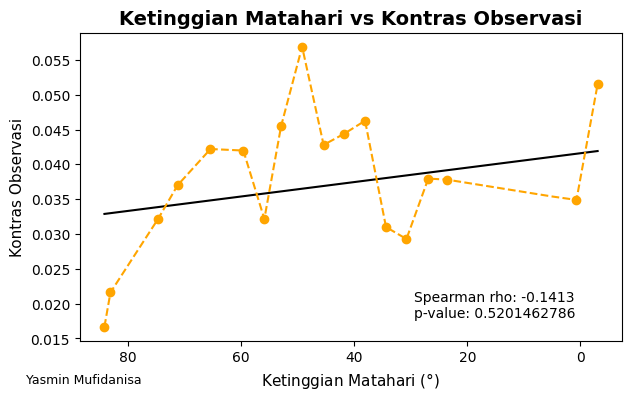

Spearman correlation: -0.141
Covariance: [[ 7.00301887e+02 -7.25567139e-02]
 [-7.25567139e-02  7.72717368e-05]]


<Figure size 640x480 with 0 Axes>

In [ ]:
fig,ax = plt.subplots(figsize=(7,4))
x = sun_alt
y = df['Observation Contrast']
coef = np.polyfit(x,y,1)
poly1d_fn = np.poly1d(coef)
plt.plot(x,poly1d_fn(x),'k')
plt.scatter(x,c_obs,color='orange')
plt.plot(x,y,color='orange',linestyle='--')
spcorr3,pval = spearmanr(x,y)
#pcorr3,_= pearsonr(c_schaefer,c_crumey)
covariance3 = cov(x,y)
plt.title('Ketinggian Matahari vs Kontras Observasi',fontsize=14,fontweight='bold',
          ha='center')
plt.xlabel(r'Ketinggian Matahari ($\degree$)',fontsize=11)
plt.ylabel('Kontras Observasi',fontsize=11)
plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),
             xy=(39,0.018),textcoords="offset points",fontsize=10)
plt.text(-0.1,-0.14 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)
ax.invert_xaxis()
plt.show()
print('Spearman correlation: %.3f' % spcorr3)
#print('Pearsons correlation: %.3f' % pcorr3)
print('Covariance:',covariance3)
plt.savefig('sun-obs.png')

<ipython-input-34-e786d3d9e5de>:14: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),


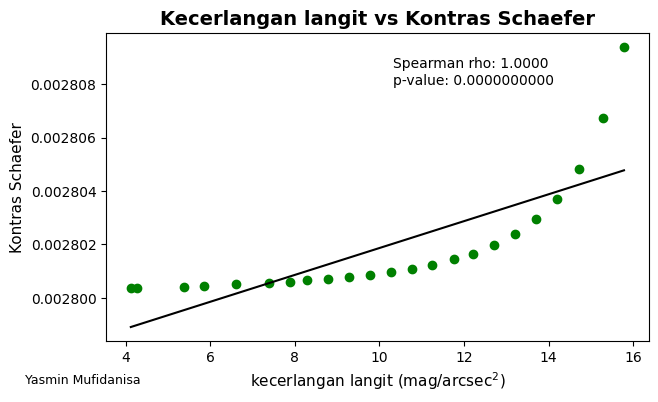

Spearman correlation: 1.000
Covariance: [[1.25344106e+01 6.31045568e-06]
 [6.31045568e-06 5.20347501e-12]]


<Figure size 640x480 with 0 Axes>

In [ ]:
fig,ax = plt.subplots(figsize=(7,4))
x = mtwi
y = c_schaefer
coef = np.polyfit(x,y,1)
poly1d_fn = np.poly1d(coef)
plt.plot(x,y,'go',x,poly1d_fn(x),'k')
spcorr3,pval = spearmanr(x,y)
#pcorr3,_= pearsonr(x,y)
covariance3 = cov(x,y)
plt.title('Kecerlangan langit vs Kontras Schaefer',fontsize=14,fontweight='bold',
          ha='center')
plt.xlabel(r'kecerlangan langit (mag/arcsec$^2$)',fontsize=11)
plt.ylabel('Kontras Schaefer',fontsize=11)
plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),
             xy=(10,0.002808),textcoords="offset points",fontsize=10)
plt.text(-0.15,-0.14 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)
#ax.invert_xaxis()
plt.show()
print('Spearman correlation: %.3f' % spcorr3)
#print('Pearsons correlation: %.3f' % pcorr3)
print('Covariance:',covariance3)
plt.savefig('mtwi-sch.png')

<ipython-input-35-7eabccc5876d>:14: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),


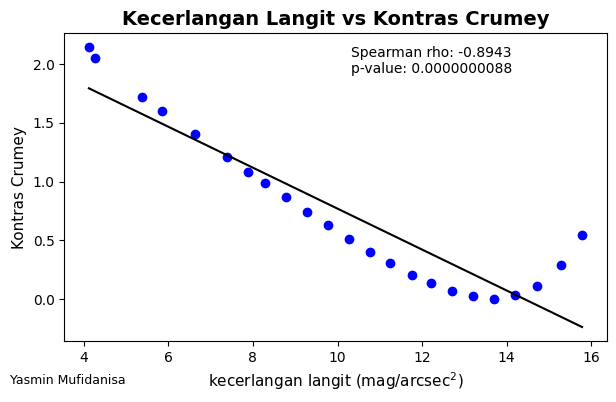

Spearman correlation: -0.894
Covariance: [[12.53441064 -2.17930093]
 [-2.17930093  0.44910395]]


<Figure size 640x480 with 0 Axes>

In [ ]:
fig,ax = plt.subplots(figsize=(7,4))
x = mtwi
y = c_crumey
coef = np.polyfit(x,y,1)
poly1d_fn = np.poly1d(coef)
plt.plot(x,y,'bo',x,poly1d_fn(x),'k')
spcorr3,pval = spearmanr(x,y)
#pcorr3,_= pearsonr(c_schaefer,c_crumey)
covariance3 = cov(x,y)
plt.title('Kecerlangan Langit vs Kontras Crumey',fontsize=14,fontweight='bold',
          ha='center')
plt.xlabel(r'kecerlangan langit (mag/arcsec$^2$)',fontsize=11)
plt.ylabel('Kontras Crumey',fontsize=11)
plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),
             xy=(10,1.9),textcoords="offset points",fontsize=10)
plt.text(-0.1,-0.14 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)
#ax.invert_xaxis()
plt.show()
print('Spearman correlation: %.3f' % spcorr3)
#print('Pearsons correlation: %.3f' % pcorr3)
print('Covariance:',covariance3)
plt.savefig('mtwi-crum.png')

<ipython-input-36-930883bd1dda>:14: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),


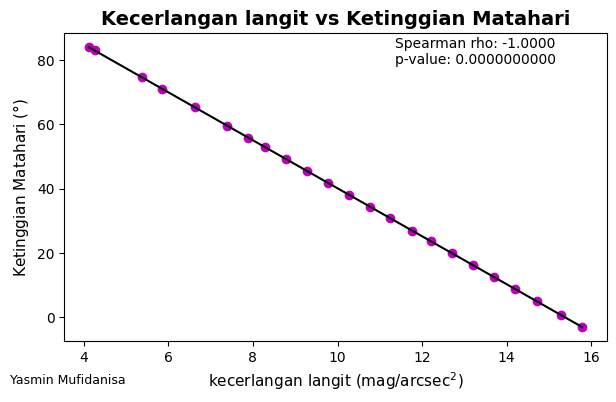

Spearman correlation: -1.000
Covariance: [[ 12.53441064 -93.69017209]
 [-93.69017209 700.30188706]]


In [ ]:
fig,ax = plt.subplots(figsize=(7,4))
x = mtwi
y = sun_alt
coef = np.polyfit(x,y,1)
poly1d_fn = np.poly1d(coef)
plt.plot(x,y,'mo',x,poly1d_fn(x),'k')
spcorr3,pval = spearmanr(x,y)
#pcorr3,_= pearsonr(c_schaefer,c_crumey)
covariance3 = cov(x,y)
plt.title('Kecerlangan langit vs Ketinggian Matahari',fontsize=14,fontweight='bold',
          ha='center')
plt.xlabel(r'kecerlangan langit (mag/arcsec$^2$)',fontsize=11)
plt.ylabel(r'Ketinggian Matahari ($\degree$)',fontsize=11)
plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),
             xy=(11,55),textcoords="offset points",fontsize=10)
plt.text(-0.1,-0.14 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)
plt.show()
print('Spearman correlation: %.3f' % spcorr3)
#print('Pearsons correlation: %.3f' % pcorr3)
print('Covariance:',covariance3)

<ipython-input-37-c3e56322fa7e>:14: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),


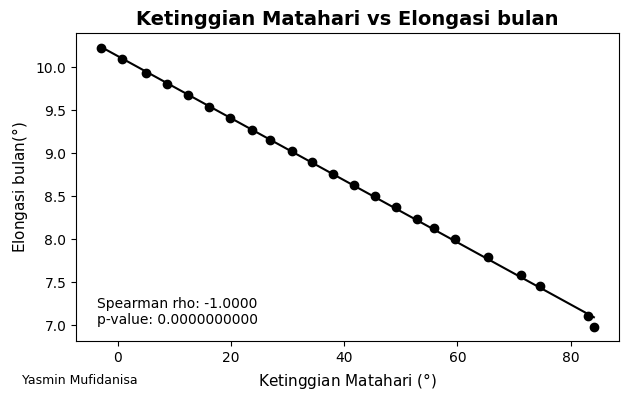

Spearman correlation: -1.000
Pearsons correlation: -1.000
Covariance: [[700.30188706 -25.32966153]
 [-25.32966153   0.91699728]]


In [ ]:
fig,ax = plt.subplots(figsize=(7,4))
x = sun_alt
y = arcl
coef = np.polyfit(x,y,1)
poly1d_fn = np.poly1d(coef)
plt.plot(x,y,'ko',x,poly1d_fn(x),'k')
spcorr3,os.POSIX_FADV_NORMAL = spearmanr(x,y)
pcorr3,_= pearsonr(x,y)
covariance3 = cov(x,y)
plt.title('Ketinggian Matahari vs Elongasi bulan',fontsize=14,fontweight='bold',
          ha='center')
plt.xlabel(r'Ketinggian Matahari ($\degree$)',fontsize=11)
plt.ylabel(r'Elongasi bulan($\degree$)',fontsize=11)
plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),
             xy=(-3,6.9),textcoords="offset points",fontsize=10)
plt.text(-0.1,-0.14 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)
plt.show()
print('Spearman correlation: %.3f' % spcorr3)
print('Pearsons correlation: %.3f' % pcorr3)
print('Covariance:',covariance3)

<ipython-input-38-5e2bcf9776dc>:14: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),


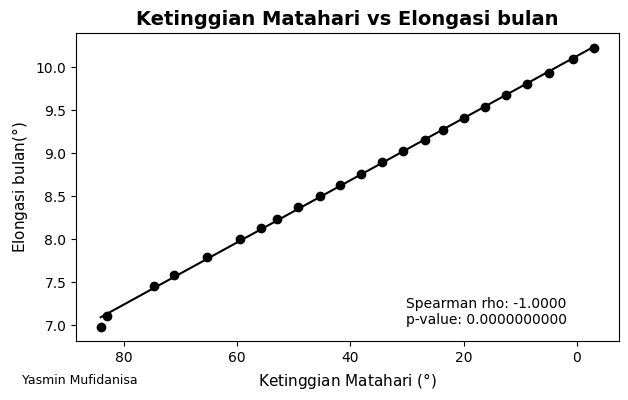

Spearman correlation: -1.000
Pearsons correlation: -1.000
Covariance: [[700.30188706 -25.32966153]
 [-25.32966153   0.91699728]]


<Figure size 640x480 with 0 Axes>

In [ ]:
fig,ax = plt.subplots(figsize=(7,4))
x = sun_alt
y = arcl
coef = np.polyfit(x,y,1)
poly1d_fn = np.poly1d(coef)
plt.plot(x,y,'ko',x,poly1d_fn(x),'k')
spcorr3,pval = spearmanr(x,y)
pcorr3,_= pearsonr(x,y)
covariance3 = cov(x,y)
plt.title('Ketinggian Matahari vs Elongasi bulan',fontsize=14,fontweight='bold',
          ha='center')
plt.xlabel(r'Ketinggian Matahari ($\degree$)',fontsize=11)
plt.ylabel(r'Elongasi bulan($\degree$)',fontsize=11)
plt.annotate('Spearman rho: {0:.4f}\np-value: {1:.10f}'.format(spcorr3,pval),
             xy=(40,6.9),textcoords="offset points",fontsize=10)
plt.text(-0.1,-0.14 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)
ax.invert_xaxis()
plt.show()
print('Spearman correlation: %.3f' % spcorr3)
print('Pearsons correlation: %.3f' % pcorr3)
print('Covariance:',covariance3)
plt.savefig('sun-arcl.png')

<ipython-input-39-fefba2a9dc71>:14: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('Spearman correlation: %.3f' % spcorr3,


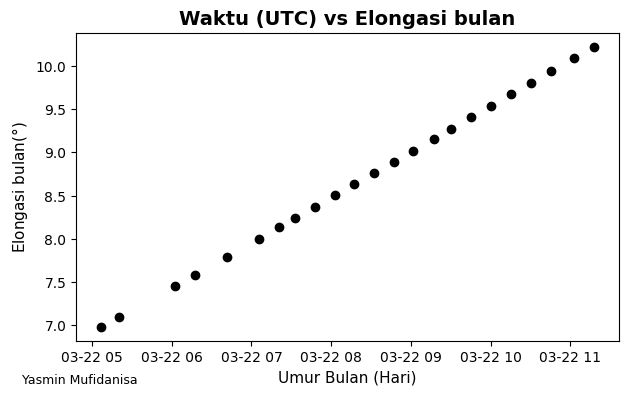

Spearman correlation: -1.000
Pearsons correlation: -1.000
Covariance: [[700.30188706 -25.32966153]
 [-25.32966153   0.91699728]]


In [ ]:
fig,ax = plt.subplots(figsize=(7,4))
x = list_t
y = arcl
#coef = np.polyfit(x,y,1)
#poly1d_fn = np.poly1d(coef)
plt.plot(x,y,'ko')#,x,poly1d_fn(x),'k')
# spcorr3,_ = spearmanr(x,y)
# pcorr3,_= pearsonr(x,y)
# covariance3 = cov(x,y)
plt.title('Waktu (UTC) vs Elongasi bulan',fontsize=14,fontweight='bold',
          ha='center')
plt.xlabel('Umur Bulan (Hari)',fontsize=11)
plt.ylabel(r'Elongasi bulan($\degree$)',fontsize=11)
plt.annotate('Spearman correlation: %.3f' % spcorr3,
             xy=(0.71,6.9),textcoords="offset points",fontsize=10)
plt.text(-0.1,-0.14 ,"Yasmin Mufidanisa", color='black', ha='left',
         transform=ax.transAxes, fontsize=9)
plt.show()
print('Spearman correlation: %.3f' % spcorr3)
print('Pearsons correlation: %.3f' % pcorr3)
print('Covariance:',covariance3)

# Analisis Statistik

In [ ]:
from sklearn.metrics import r2_score
from scipy.stats import chi2_contingency

x = c_schaefer
y = c_crumey
r2 = r2_score(x, y)

rho,pval = spearmanr(x,y)

# create contingency table
observed = np.array([x, y])

# perform chi-square test
chi2, p_val, dof, expected = chi2_contingency(observed)

print('spearman:',rho)
print('pvalue:',pval)
print('chi-square:', chi2)
print('p-value:', p_val)
print('r2 score for perfect model is', r2)

spearman: -0.8942687747035574
pvalue: 8.848052618819326e-09
chi-square: 0.5427266443329442
p-value: 0.9999999999999886
r2 score for perfect model is -196453250648.7265


In [ ]:
from sklearn.metrics import r2_score
from scipy.stats import chi2_contingency

x = c_schaefer
y = df['Observation Contrast']
r2 = r2_score(x, y)

# create contingency table
observed = np.array([x, y])

# perform chi-square test
chi2, p_val, dof, expected = chi2_contingency(observed)

print('chi-square:', chi2)
print('p-value:', p_val)
print('r2 score for perfect model is', r2)

chi-square: 0.003987345572734951
p-value: 1.0
r2 score for perfect model is -257517175.70155513


In [ ]:
from sklearn.metrics import r2_score
from scipy.stats import chi2_contingency
from scipy import stats
x = c_crumey
y = df['Observation Contrast']
r2 = r2_score(x, y)

stat = stats.spearmanr(x, y)

# create Spearman Correlation
spcorr,pval = spearmanr(x,y)

# create contingency table
observed = np.array([x, y])

# perform chi-square test
chi2, p_val, dof, expected = chi2_contingency(observed)

print('Spearman rho:', spcorr)
print(stat.statistic)
print(stat.pvalue)
print('pvalue:',pval)
print('chi-square:', chi2)
print('p-value:', p_val)
print('r2 score for perfect model is', r2)

Spearman rho: -0.06027667984189724
-0.06027667984189724
0.7846962247332138
pvalue: 0.7846962247332138
chi-square: 2.1789832251665486
p-value: 0.9999999762228574
r2 score for perfect model is -1.1680555560377868


In [ ]:
from sklearn.metrics import r2_score
from scipy.stats import chi2_contingency

x = c_crumey
y = mtwi
r2 = r2_score(x, y)

# create contingency table
observed = np.array([x, y])

# perform chi-square test
chi2, p_val, dof, expected = chi2_contingency(observed)
res = ttest_ind(x, y).pvalue

print('chi-square:', chi2)
print('p-value:', p_val)
print('p-value2:',res)
print('r2 score for perfect model is', r2)

chi-square: 29.780082980970427
p-value: 0.12390824898269472
p-value2: 4.19995848944346e-16
r2 score for perfect model is -243.68384231676842


In [ ]:
from sklearn.metrics import r2_score
from scipy.stats import chi2_contingency

x = mtwi
y = c_crumey
r2 = r2_score(x, y)

# create contingency table
observed = np.array([x, y])

# perform chi-square test
chi2, p_val, dof, expected = chi2_contingency(observed)
res = ttest_ind(x, y).pvalue

print('chi-square:', chi2)
print('p-value:', p_val)
print('p-value2:',res)
print('r2 score for perfect model is', r2)

chi-square: 29.78008298097043
p-value: 0.12390824898269458
p-value2: 4.19995848944346e-16
r2 score for perfect model is -7.7669443851285305


In [ ]:
from sklearn.metrics import r2_score
from scipy.stats import chi2_contingency

x = mtwi
y = c_schaefer
r2 = r2_score(x, y)

# create contingency table
observed = np.array([x, y])

# perform chi-square test
chi2, p_val, dof, expected = chi2_contingency(observed)
res = ttest_ind(x, y).pvalue

print('chi-square:', chi2)
print('p-value:', p_val)
print('p-value:',res)
print('r2 score for perfect model is', r2)

chi-square: 0.010386795160832879
p-value: 1.0
p-value: 1.5663960143062988e-17
r2 score for perfect model is -8.591182004747257


In [ ]:
from sklearn.metrics import r2_score
from scipy.stats import chi2_contingency

x = sun_alt[0:17]
y = arcl[0:17]
r2 = r2_score(x, y)

# create contingency table
observed = np.array([x, y])

# perform chi-square test
chi2, p_val, dof, expected = chi2_contingency(observed)
res = ttest_ind(x, y).pvalue

print('chi-square:', chi2)
print('p-value:', p_val)
print('p-value2:',res)
print('r2 score for perfect model is', r2)

chi-square: 32.29902301781133
p-value: 0.009140381660966467
p-value2: 1.0421208720490739e-09
r2 score for perfect model is -4.59195140923999
